In [6]:
# Import required modules
import datetime
from datetime import timedelta
import contextily as ctx
from adjustText import adjust_text
from dask import compute
import geopandas as gpd
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
from pathlib import Path
from pprint import pprint
from shapely.geometry import Point
import warnings
import xarray as xr

%matplotlib notebook

# Add that all figures should be inlined
%matplotlib inline

## Read data

In [7]:
catchment = "chena"
swe_observations_path = f'/anvil/projects/x-ees240082/users/dcasson/gpep/{catchment}/snow_data/{catchment}_NorSWE.nc'
basin_gpkg_path = f'/anvil/projects/x-ees240082/users/dcasson/gpep/{catchment}/gis/{catchment}_tdx.gpkg'
hru_csv_path = f'/anvil/projects/x-ees240082/users/dcasson/gpep/{catchment}/gis/stations_with_hru_ids.csv' 
start_date = '2008-10-01'
end_date = '2018-10-01'


In [8]:
def filter_stations_by_obs_per_year(ds, var='snw', n=1, start_date='2010-01-01', end_date='2021-12-31'):
    """
    Filters stations based on a minimum number of valid observations per year for a given variable.

    Parameters:
        ds (xarray.Dataset): Dataset with dimensions (time, station_id)
        var (str): Variable to check (e.g., 'snw')
        n (int): Minimum number of valid observations per year
        start_date (str): Start date for filtering
        end_date (str): End date for filtering

    Returns:
        xarray.Dataset: Dataset filtered to include only qualifying station_ids
    """
    # 1. Restrict to desired time range
    ds_filtered = ds.sel(time=slice(start_date, end_date))

    # 2. Identify valid observations (non-NaN)
    valid = ~ds_filtered[var].isnull()

    # 3. Extract years using .dt accessor
    years = ds_filtered.time.dt.year

    # 4. Group by year and sum valid obs per station per year
    obs_per_year = valid.groupby(xr.DataArray(years, coords={"time": ds_filtered.time}, dims="time").rename("year")).sum(dim="time")

    # 5. Check that all years for a station meet the n threshold
    station_mask = (obs_per_year >= n).all(dim="year")

    # 6. Apply mask to original filtered dataset
    return ds_filtered.sel(station_id=ds_filtered.station_id[station_mask])

<xarray.Dataset> Size: 9MB
Dimensions:        (station_id: 18, time: 15706)
Coordinates:
  * time           (time) datetime64[ns] 126kB 1979-01-01 ... 2021-12-31
  * station_id     (station_id) <U13 936B 'NRCS-AK-46Q01' ... 'SNOTEL-952'
Data variables: (12/14)
    lat            (station_id) float32 72B ...
    lon            (station_id) float32 72B ...
    elevation      (station_id) float32 72B ...
    source         (station_id) <U41 3kB ...
    station_name   (station_id) <U33 2kB ...
    type_mes       (station_id) uint8 18B ...
    ...             ...
    snd            (time, station_id) float32 1MB ...
    den            (time, station_id) float32 1MB ...
    data_flag_snw  (time, station_id) <U2 2MB ...
    data_flag_snd  (time, station_id) <U1 1MB ...
    qc_flag_snw    (time, station_id) <U1 1MB ...
    qc_flag_snd    (time, station_id) <U1 1MB ...
Attributes:
    Conventions:    CF-1.9
    Title:          Northern Hemisphere in situ SWE 1979-2021 v3
    Latest_update:  Apr

<xarray.Dataset> Size: 498kB
Dimensions:        (station_id: 4, time: 3653)
Coordinates:
  * time           (time) datetime64[ns] 29kB 2008-10-01 ... 2018-10-01
  * station_id     (station_id) <U13 208B 'SNOTEL-948' ... 'SNOTEL-951'
Data variables: (12/14)
    lat            (station_id) float32 16B ...
    lon            (station_id) float32 16B ...
    elevation      (station_id) float32 16B ...
    source         (station_id) <U41 656B ...
    station_name   (station_id) <U33 528B ...
    type_mes       (station_id) uint8 4B ...
    ...             ...
    snd            (time, station_id) float32 58kB ...
    den            (time, station_id) float32 58kB ...
    data_flag_snw  (time, station_id) <U2 117kB ...
    data_flag_snd  (time, station_id) <U1 58kB ...
    qc_flag_snw    (time, station_id) <U1 58kB ...
    qc_flag_snd    (time, station_id) <U1 58kB ...
Attributes:
    Conventions:    CF-1.9
    Title:          Northern Hemisphere in situ SWE 1979-2021 v3
    Latest_update:  April 2025
    Source:         Environment and Climate Change Canada and partners (https...
    Distribution:   CanSWE data are redistributed under the Open Government L...
    Comment:        See Vionnet et al. (ESSD, 2021) for a description of the ...

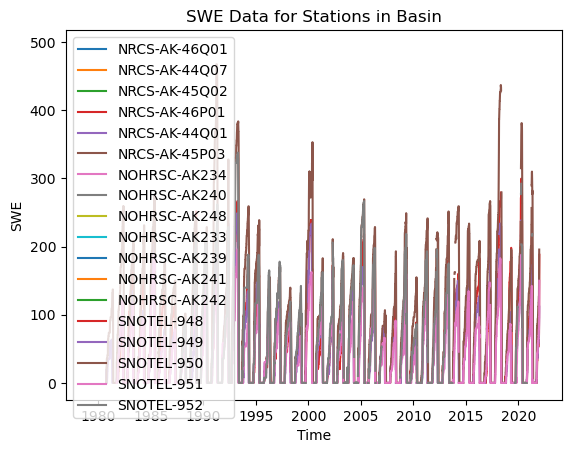

[ 77. 120.  16. 116. 120. 224. 138. 285. 214.  32.  37.  35. 112. 162.
  16. 116. 224. 120.]


In [9]:
# Read SWE station observations NetCDF
SWE_stations_ds_complete = xr.open_dataset(swe_observations_path)
print(SWE_stations_ds_complete)

SWE_stations_ds = filter_stations_by_obs_per_year(SWE_stations_ds_complete, var='snw', n=2, start_date=start_date, end_date=end_date)
display(SWE_stations_ds)
SWE_stations_ds = SWE_stations_ds_complete
# Plot the SWE data for the stations in the basin
plt.plot(SWE_stations_ds.time, SWE_stations_ds.snw, label=SWE_stations_ds.station_id.values)
plt.title('SWE Data for Stations in Basin')
plt.xlabel('Time')
plt.ylabel('SWE')
plt.legend()
plt.show()

#Read hru ids csv
hru_ids = pd.read_csv(hru_csv_path)

# Match the station_id to return the gru_id
gru_ids = hru_ids[hru_ids['station_id'].isin(SWE_stations_ds.station_id.values)]['GRU_ID'].values
print(gru_ids)


You can zoom into the map with the rectangle icon ("zoom to rectangle") showing below the figure. Here, you see that the sample data contains SWE station observations for an area around two river basins, one in the USA and one in Canada, for which we also have all the data needed to run this workflow (e.g., discharge observations).

We will now extract the SWE station observations in the test basin and make a few plots.

  Plotting 'RF Static Dynamic' (deterministic=False) for HRU 77.0


/tmp/ipykernel_3835626/2781261584.py:42: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 500. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(nc, chunks={'time': 500})
/tmp/ipykernel_3835626/2781261584.py:42: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 500. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(nc, chunks={'time': 500})
/tmp/ipykernel_3835626/2781261584.py:42: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 500. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(nc, chunks={'time': 500})
/tmp/ipykernel_3835626/2781261584.py:42: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 500. This could degrade performance. I

NameError: name 'station_name' is not defined

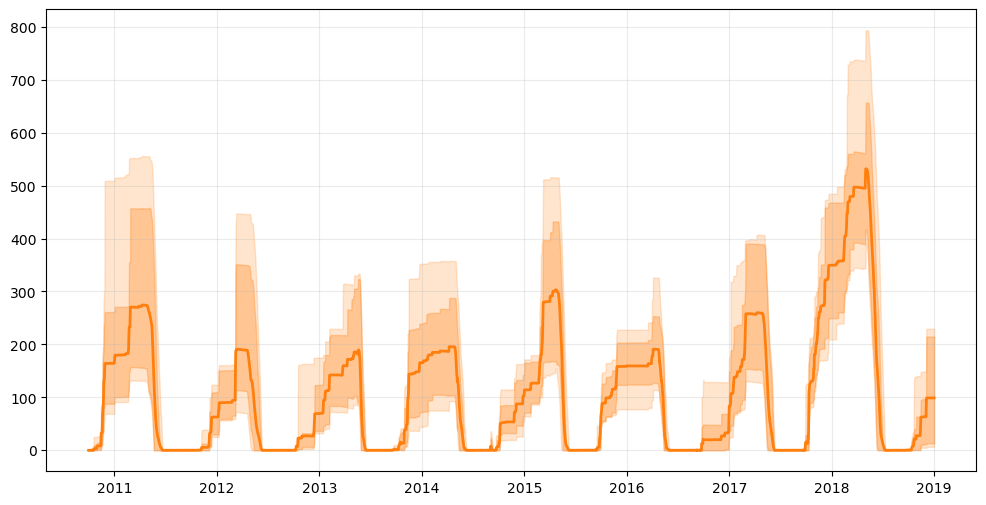

In [10]:
def read_station_data_by_gru(ds, gru_id, station_id_to_gru):
    matching_ids = station_id_to_gru[station_id_to_gru['GRU_ID'] == gru_id]['station_id'].values
    station_ids = ds['station_id'].load().values
    station_names = ds['station_name'].load().values
    matching_indices = [i for i, sid in enumerate(station_ids) if sid in matching_ids]
    snw_subset = ds['snw'].isel(station_id=matching_indices).load()
    return {
        str(station_names[i]): snw_subset.isel(station_id=j)
        for j, i in enumerate(matching_indices)
    }


def plot_multiple_ensembles(ensemble_specs, station_data_dict,
                            variable_name, hru_id, output_path,
                            time_range=None):
    fig, ax = plt.subplots(figsize=(12, 6))

    for spec in ensemble_specs:
        label = spec['label']
        files = spec['files']
        color = spec.get('color', 'k')
        is_det = spec.get('deterministic', False)

        print(f"  Plotting '{label}' (deterministic={is_det}) for HRU {hru_id}")

        if is_det:
            # --- deterministic: just one file, one line ---
            nc = files[0]
            ds = xr.open_dataset(nc, chunks={'time': 500})
            hru_dim = next((d for d in ds.dims if d.lower().startswith('hru')), None)
            da = ds[variable_name].sel({hru_dim: hru_id})
            time = da['time'].values
            vals = da.values
            ax.plot(time, vals,
                    color=color, linestyle='--', linewidth=2,
                    label=f"{label} (det)")
            continue

        # --- ensemble: build lazy, chunked member×time array ---
        das = []
        for nc in files:
            ds = xr.open_dataset(nc, chunks={'time': 500})
            if variable_name not in ds:
                continue
            hru_dim = next((d for d in ds.dims if d.lower().startswith('hru')), None)
            da = ds[variable_name].sel({hru_dim: hru_id})
            das.append(da)

        if not das:
            print(f"    No members for '{label}', skipping")
            continue

        ensemble = xr.concat(
            das,
            dim='member',
            join='outer',
            compat='override',
            coords='minimal'
        ).chunk({'member': -1})

        # lazy stats
        mean_da = ensemble.mean(dim='member')
        p10_da  = ensemble.quantile(0.1, dim='member')
        p90_da  = ensemble.quantile(0.9, dim='member')
        vmin_da = ensemble.min(dim='member')
        vmax_da = ensemble.max(dim='member')

        mean, p10, p90, vmin, vmax = compute(mean_da, p10_da, p90_da, vmin_da, vmax_da)
        time = ensemble['time'].values

        ax.fill_between(time, vmin, vmax,
                        color=color, alpha=0.2,
                        label=f"{label} Max–Min")
        ax.fill_between(time, p10, p90,
                        color=color, alpha=0.3,
                        label=f"{label} 10–90%")
        ax.plot(time, mean,
                color=color, linewidth=2,
                label=f"{label} Mean")
        
        ax.grid(True, alpha=0.25)
        ax.set_title(station_name, loc="left", fontsize=10)

    # station obs
    for name, da in station_data_dict.items():
        ax.scatter(da['time'], da.values,
                   label=f"Obs: {name}", s=10, color='C0')

    #ax.set_title(f"{name} | GRU={gru_id} | {variable_name}")
    ax.set_xlabel("Time")
    ax.set_ylabel(variable_name)
    ax.legend(loc='upper left', fontsize='small', ncol=2)
    ax.grid(True)

    if time_range:
        start, end = time_range
        ax.set_xlim(mdates.datestr2num(start), mdates.datestr2num(end))

    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    fig.autofmt_xdate()

    Path(output_path).parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(output_path, bbox_inches='tight')
    plt.show()
    plt.close(fig)


# -----------------------------
# Configuration
ensemble_sources = [
    {
        'label': 'RF Static Dynamic',
        'dir': f'/anvil/projects/x-ees240082/users/dcasson/gpep/{catchment}/ensemble_generation/rf_best_regression_static_dynamic/summa/output/',
        'color': 'C1',
        'deterministic': False
    },
    #{
    #    'label': 'LWR Static',
    #    'dir': f'/anvil/projects/x-ees240082/users/dcasson/gpep/{catchment}/ensemble_generation/lwr_best_regression_static/summa/output/',
    #    'color': 'C2',
    #    'deterministic': False
    #},
    {
        'label': 'CASR',
        'dir': f'/anvil/projects/x-ees240082/users/dcasson/gpep/{catchment}/ensemble_generation/casr_remapped/summa_output',
        'color': 'C3',
        'deterministic': True
    },
    
    # Add more sources here as needed
]
figure_directory = Path(f'/anvil/projects/x-ees240082/users/dcasson/gpep/{catchment}/ensemble_generation/swe_figures_rf_compare/')
figure_directory.mkdir(parents=True, exist_ok=True)
variable_name = 'scalarSWE'
# load stations
SWE_stations_ds_complete = xr.open_dataset(swe_observations_path)
SWE_stations_ds = filter_stations_by_obs_per_year(
    SWE_stations_ds_complete, var='snw', n=0,
    start_date=start_date, end_date=end_date
)

hru_ids = pd.read_csv(hru_csv_path)
station_ids_in_ds = SWE_stations_ds['station_id'].values
station_id_to_gru = hru_ids[hru_ids['station_id'].isin(station_ids_in_ds)]
unique_gru_ids = station_id_to_gru['GRU_ID'].unique()

for gru_id in unique_gru_ids:
    station_data = read_station_data_by_gru(
        SWE_stations_ds, gru_id, station_id_to_gru
    )
    if not station_data:
        continue

    specs = []
    for src in ensemble_sources:
        files = [
            os.path.join(src['dir'], f)
            for f in os.listdir(src['dir'])
            if f.endswith('.nc') and any(f"G{int(gru_id):{pad}d}" in f for pad in ['02','03','04'])
        ]
        if files:
            specs.append({'label': src['label'],
                          'files': files,
                          'color': src['color'],
                          'deterministic': src['deterministic']})

    if not specs:
        continue

    hru_match = hru_ids[hru_ids['GRU_ID'] == gru_id]['HRU_ID'].values
    if hru_match.size == 0:
        continue
    hru_id = int(hru_match[0])

    out = figure_directory / f"compare_GRU_{int(gru_id):04d}_HRU_{hru_id}.png"
    plot_multiple_ensembles(
        specs, station_data, variable_name,
        gru_id, out,
        time_range=('2010-08-01', '2018-10-31')
    )


In [11]:
import os
import pandas as pd
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path
from typing import Union
from sklearn.metrics import mean_absolute_error, mean_squared_error
from scipy.stats import pearsonr, spearmanr

# --- Statistical metrics ---
def mae(obs: Union[np.ndarray, pd.Series], sim: Union[np.ndarray, pd.Series]) -> float:
    obs_arr = np.asarray(obs, dtype=float).ravel()
    sim_arr = np.asarray(sim, dtype=float).ravel()  
    mask = ~np.isnan(obs_arr) & ~np.isnan(sim_arr)
    if mask.sum() == 0:
        return np.nan
    return mean_absolute_error(obs_arr[mask], sim_arr[mask])

def rmse(obs: Union[np.ndarray, pd.Series], sim: Union[np.ndarray, pd.Series]) -> float:
    obs_arr = np.asarray(obs, dtype=float).ravel()
    sim_arr = np.asarray(sim, dtype=float).ravel()
    mask = ~np.isnan(obs_arr) & ~np.isnan(sim_arr)
    if mask.sum() == 0:
        return np.nan
    return mean_squared_error(obs_arr[mask], sim_arr[mask], squared=False)

def corr_Pearson(obs: Union[np.ndarray, pd.Series], sim: Union[np.ndarray, pd.Series]) -> float:
    obs_arr = np.asarray(obs, dtype=float).ravel()
    sim_arr = np.asarray(sim, dtype=float).ravel()
    mask = ~np.isnan(obs_arr) & ~np.isnan(sim_arr)
    if mask.sum() < 2:
        return np.nan
    return pearsonr(obs_arr[mask], sim_arr[mask])[0]

def corr_Spearman(obs: Union[np.ndarray, pd.Series], sim: Union[np.ndarray, pd.Series]) -> float:
    obs_arr = np.asarray(obs, dtype=float).ravel()
    sim_arr = np.asarray(sim, dtype=float).ravel()
    mask = ~np.isnan(obs_arr) & ~np.isnan(sim_arr)
    if mask.sum() < 2:
        return np.nan
    return spearmanr(obs_arr[mask], sim_arr[mask])[0]

def nrmse_adimMax(obs: Union[np.ndarray, pd.Series], sim: Union[np.ndarray, pd.Series]) -> float:
    obs_arr = np.asarray(obs, dtype=float).ravel()
    sim_arr = np.asarray(sim, dtype=float).ravel()
    mask = ~np.isnan(obs_arr) & ~np.isnan(sim_arr)
    if mask.sum() == 0:
        return np.nan
    e = rmse(obs_arr[mask], sim_arr[mask])
    max_obs = np.nanmax(obs_arr[mask])
    return e / max_obs if max_obs != 0 else np.nan

def nrmse_adimSD(obs: Union[np.ndarray, pd.Series], sim: Union[np.ndarray, pd.Series]) -> float:
    obs_arr = np.asarray(obs, dtype=float).ravel()
    sim_arr = np.asarray(sim, dtype=float).ravel()
    mask = ~np.isnan(obs_arr) & ~np.isnan(sim_arr)
    if mask.sum() == 0:
        return np.nan
    e = rmse(obs_arr[mask], sim_arr[mask])
    sd_obs = np.nanstd(obs_arr[mask], ddof=1)
    return e / sd_obs if sd_obs != 0 else np.nan

# --- Read station observations per GRU ---
def read_station_data_by_gru(ds, gru_id, station_map):
    ids = station_map.loc[station_map['GRU_ID'] == gru_id, 'station_id'].values
    station_ids = ds['station_id'].load().values
    station_names = ds['station_name'].load().values
    indices = [i for i, sid in enumerate(station_ids) if sid in ids]
    snw = ds['snw'].isel(station_id=indices).load()
    return {
        str(station_names[i]): snw.isel(station_id=j)
        for j, i in enumerate(indices)
    }


# --- Plot ensemble vs observations, with deterministic support ---
def plot_multiple_ensembles(ensemble_specs, station_data, var_name,
                            output_path, time_range=None):
    fig, ax = plt.subplots(figsize=(12, 6))

    for spec in ensemble_specs:
        label = spec['label']
        files = spec['files']
        color = spec.get('color', 'k')
        is_det = spec.get('deterministic', False)

        print(f"Plotting source '{label}' (deterministic={is_det})")

        if is_det:
            # single deterministic file
            ds = xr.open_dataset(files[0])
            da = ds[var_name].resample(time='1D').mean()
            time = da['time'].values
            vals = da.values
            ax.plot(time, vals,
                    linestyle='--', linewidth=2,
                    color=color, label=f"{label} (deterministic)")
            continue

        # ensemble processing
        ensemble_vals = []
        time = None
        for nc in files:
            print(f"  Loading {nc}")
            ds = xr.open_dataset(nc)
            if var_name not in ds:
                continue
            daily = ds[var_name].resample(time='1D').mean()
            ensemble_vals.append(daily.values)
            if time is None:
                time = daily['time'].values

        if not ensemble_vals:
            print(f"  No data for '{label}', skipping")
            continue

        arr = np.array(ensemble_vals)
        mean = np.nanmean(arr, axis=0)
        p10, p90 = np.nanpercentile(arr, [10, 90], axis=0)
        vmin, vmax = np.nanmin(arr, axis=0), np.nanmax(arr, axis=0)

        ax.fill_between(time, vmin, vmax,
                        color=color, alpha=0.2,
                        label=f"{label} max–min")
        ax.fill_between(time, p10, p90,
                        color=color, alpha=0.3,
                        label=f"{label} 10–90th pct")
        ax.plot(time, mean,
                color=color, linewidth=2,
                label=f"{label} mean")

    print("Plotting station observations...")
    for name, da in station_data.items():
        ax.scatter(da['time'], da.values,
                   s=10, label=f"Obs {name}")

    ax.set_xlabel('Time')
    ax.set_ylabel(var_name)
    if time_range:
        ax.set_xlim(mdates.datestr2num(time_range[0]),
                    mdates.datestr2num(time_range[1]))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    fig.autofmt_xdate()
    ax.grid(True)
    ax.legend(loc='upper left', fontsize='small', ncol=2)

    Path(output_path).parent.mkdir(parents=True, exist_ok=True)
    print(f"Saving figure to {output_path}")
    plt.savefig(output_path, bbox_inches='tight')
    plt.close(fig)

# --- CDF of metrics ---
def plot_metrics_cdf(df, metric, output_path):
    fig, ax = plt.subplots(figsize=(8, 4))
    for src in df['Source'].unique():
        vals = df.loc[df['Source'] == src, metric].dropna().values
        if len(vals) == 0:
            continue
        sorted_vals = np.sort(vals)
        ecdf = np.arange(1, len(sorted_vals) + 1) / len(sorted_vals)
        ax.plot(sorted_vals, ecdf, label=src)
    ax.set_title(f"CDF of {metric}")
    ax.set_xlabel(metric)
    ax.set_ylabel('ECDF')
    ax.grid(True)
    ax.legend()
    Path(output_path).parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(output_path, bbox_inches='tight')
    plt.close(fig)

# --- Main processing ---
if __name__ == "__main__":
    # Configuration
    ensemble_sources = [
    {
        'label': 'CASR',
        'dir': '/anvil/projects/x-ees240082/users/dcasson/gpep/bow/ensemble_generation/rf_best_regression_static_dynamic/summa/output_casr',
        'color': 'C0',
        'deterministic': True
    },
        {
        'label': 'EM-Earth ERA5',
        'dir': '/anvil/projects/x-ees240082/users/dcasson/gpep/bow/ensemble_generation/rf_best_regression_static_dynamic/summa/output_em_earth',
        'color': 'C0',
        'deterministic': True
    },
    {
        'label': 'Base',
        'dir': '/anvil/projects/x-ees240082/users/dcasson/gpep/bow/ensemble_generation/rf_best_regression_static_dynamic/summa/output_base/',
        'color': 'C1',
        'deterministic': False
    },
    {
        'label': 'GBM - Corr',
        'dir': '/anvil/projects/x-ees240082/users/dcasson/gpep/bow/ensemble_generation/rf_best_regression_static_dynamic/summa/output_gbm_corr/',
        'color': 'C2',
        'deterministic': False
    },
    {
        'label': 'GBM - RMSE',
        'dir': '/anvil/projects/x-ees240082/users/dcasson/gpep/bow/ensemble_generation/rf_best_regression_static_dynamic/summa/output_gbm_rmse/',
        'color': 'C2',
        'deterministic': False
    },
            {
        'label': 'RF - Corr',
        'dir': '/anvil/projects/x-ees240082/users/dcasson/gpep/bow/ensemble_generation/rf_best_regression_static_dynamic/summa/output_rf_corr/',
        'color': 'C2',
        'deterministic': False
    },
            {
        'label': 'RF - RMSE',
        'dir': '/anvil/projects/x-ees240082/users/dcasson/gpep/bow/ensemble_generation/rf_best_regression_static_dynamic/summa/output_rf_rmse/',
        'color': 'C2',
        'deterministic': False
    },
    ]
    swe_obs_path = '/anvil/projects/x-ees240082/users/dcasson/gpep/bow/snow_data/Bow_NorSWE.nc'
    hru_csv_path = '/anvil/projects/x-ees240082/users/dcasson/gpep/bow/gis/stations_with_hru_ids.csv'
    variable_name = 'scalarSWE'
    figure_dir = Path('./swe_figures/')
    metrics_csv = 'ensemble_metrics_hidden_stations.csv'
    metrics_cdf_dir = Path('./metrics_cdf/')
    time_range=('2010-08-01','2018-12-31')
    
    # Load and filter observations
    ds_obs  = xr.open_dataset(swe_obs_path)
    ds_filt = filter_stations_by_obs_per_year(
        ds_obs, var='snw', n=1,
        start_date=time_range[0], end_date=time_range[1]
    )
    hru_map     = pd.read_csv(hru_csv_path)
    station_map = hru_map[hru_map['station_id'].isin(ds_filt['station_id'].values)]
    unique_grus = station_map['GRU_ID'].unique()
    grus_to_exclude = [1024, 1163]

    unique_grus = [g for g in station_map['GRU_ID'].unique()
                if g not in grus_to_exclude]
    print(f"→ will process GRUs: {unique_grus}")
    metrics = []
    for gru in unique_grus:
        print(f"Processing GRU {gru}")
        station_data = read_station_data_by_gru(ds_filt, gru, station_map)
        if not station_data:
            continue

        # build specs for this GRU
        specs = []
        for src in ensemble_sources:
            files = [
                os.path.join(src['dir'], f)
                for f in os.listdir(src['dir'])
                if f.endswith('.nc') and f"G{int(gru):04d}" in f
            ]
            if files:
                specs.append({
                    'label':        src['label'],
                    'files':        files,
                    'color':        src['color'],
                    'deterministic': src['deterministic']
                })
        if not specs:
            continue

        # compute metrics for each source
        for spec in specs:
            label = spec['label']
            print(f"  Calculating metrics for {label}")

            if spec['deterministic']:
                # single run → daily mean
                ds = xr.open_dataset(spec['files'][0])
                daily = ds[variable_name].resample(time='1D').mean()
                mean_ts = daily.values
                mean_ts = np.squeeze(mean_ts) 
                sim_times = pd.to_datetime(daily['time'].values)
            else:
             # --- ENSEMBLE: build one Series per member, union times ---
                series_list = []
                for nc in spec['files']:
                    ds = xr.open_dataset(nc)
                    daily = ds[variable_name].resample(time='1D').mean()
                    times = pd.to_datetime(daily['time'].values)
                    vals = np.squeeze(daily.values)
                    series_list.append(pd.Series(vals, index=times))

                # union index, fill missing with NaN, then mean
                df_ens      = pd.concat(series_list, axis=1)
                mean_series = df_ens.mean(axis=1, skipna=True)

                sim_times = mean_series.index
                mean_ts    = mean_series.values
                mean_ts = np.squeeze(mean_ts) 

            # align observations & simulation by intersecting dates
            sim_series = pd.Series(mean_ts, index=sim_times)

            for name, da in station_data.items():
                obs_times = pd.to_datetime(da['time'].values)
                obs_series = pd.Series(da.values, index=obs_times)

                common_idx = obs_series.index.intersection(sim_series.index)
                if common_idx.empty:
                    continue

                obs_clean = obs_series.loc[common_idx].values
                sim_clean = sim_series.loc[common_idx].values
                n_obs = len(common_idx)

                metrics.append({
                    'GRU_ID':    gru,
                    'Station':   name,
                    'Source':    label,
                    'N_obs':     n_obs,
                    'MAE':       mae(obs_clean, sim_clean),
                    'RMSE':      rmse(obs_clean, sim_clean),
                    'Pearson':   corr_Pearson(obs_clean, sim_clean),
                    'Spearman':  corr_Spearman(obs_clean, sim_clean),
                    'NRMSE_max': nrmse_adimMax(obs_clean, sim_clean),
                    'NRMSE_sd':  nrmse_adimSD(obs_clean, sim_clean)
                })

    # Save metrics CSV
    df = pd.DataFrame(metrics)
    df.to_csv(metrics_csv, index=False)
    print(f"Saved metrics to {metrics_csv}")

    # Plot CDFs
    def plot_metrics_cdf(df, metric, output_path):
        fig, ax = plt.subplots(figsize=(8, 4))
        for src in df['Source'].unique():
            vals = df.loc[df['Source'] == src, metric].dropna().values
            if len(vals) == 0:
                continue
            sorted_vals = np.sort(vals)
            ecdf = np.arange(1, len(sorted_vals)+1) / len(sorted_vals)
            ax.plot(sorted_vals, ecdf, label=src)
        ax.set_title(f"CDF of {metric}")
        ax.set_xlabel(metric)
        ax.set_ylabel('ECDF')
        ax.grid(True)
        ax.legend()
        Path(output_path).parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(output_path, bbox_inches='tight')
        plt.close(fig)

    for m in ['N_obs','MAE','RMSE','Pearson','Spearman','NRMSE_max','NRMSE_sd']:
        plot_metrics_cdf(df, m, metrics_cdf_dir / f"cdf_{m}.png")

    print(f"Generated CDFs in {metrics_cdf_dir}")


FileNotFoundError: [Errno 2] No such file or directory: '/anvil/projects/x-ees240082/users/dcasson/gpep/bow/snow_data/Bow_NorSWE.nc'

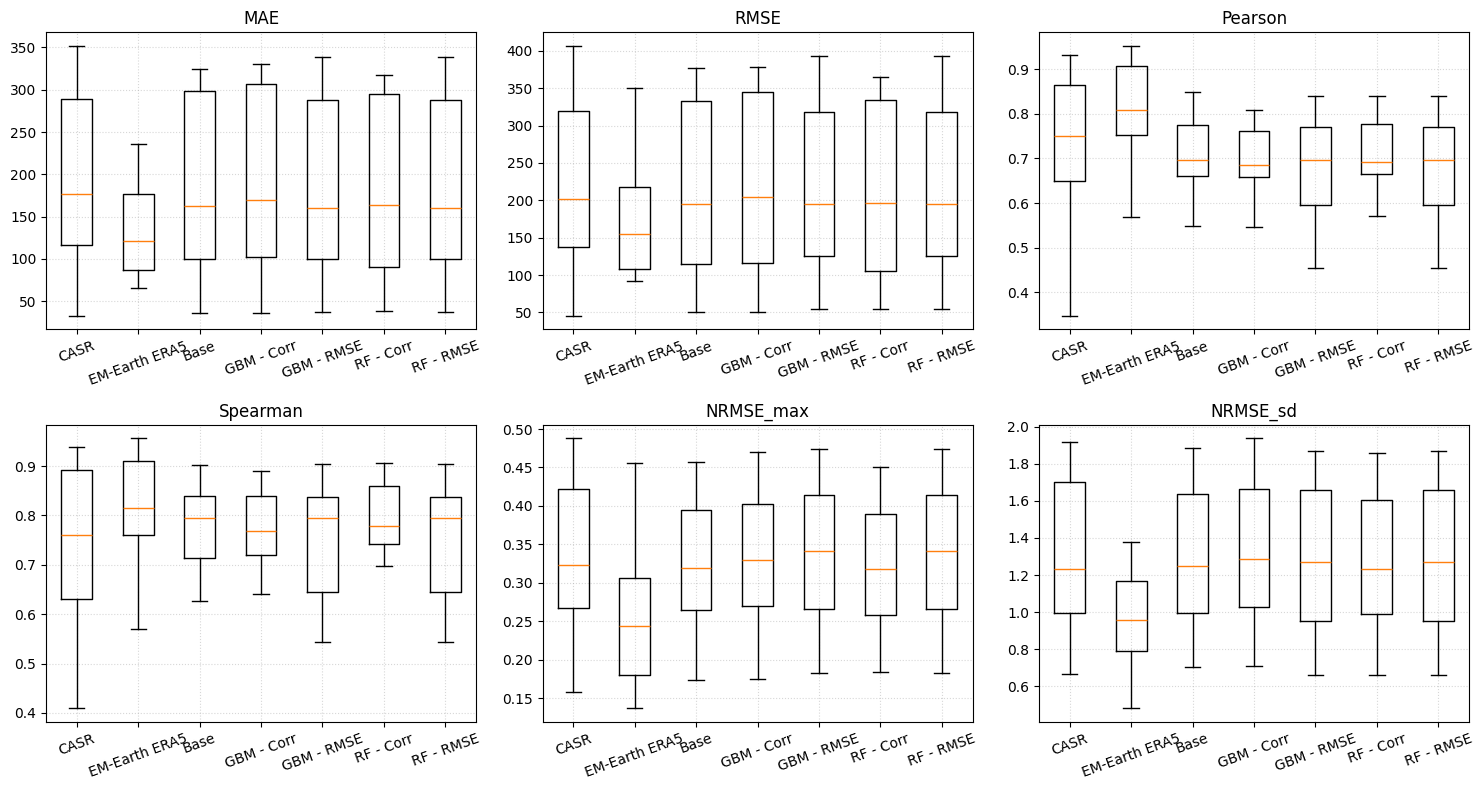

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# --- Load metrics CSV ---
metrics_csv = 'ensemble_metrics_hidden_stations.csv'
df = pd.read_csv(metrics_csv)

# --- Configuration ---
metrics = ['MAE','RMSE','Pearson','Spearman','NRMSE_max','NRMSE_sd']
sources = df['Source'].unique()
n = len(metrics)
ncols = 3
nrows = (n + ncols - 1)//ncols

# --- Plot ---
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5*ncols, 4*nrows))
axes = axes.flatten()

for ax, metric in zip(axes, metrics):
    # prepare data for each Source
    data = [ df.loc[df['Source']==src, metric].dropna().values
             for src in sources ]
    ax.boxplot(data, labels=sources, showfliers=False)
    ax.set_title(metric)
    ax.tick_params(axis='x', rotation=20)
    ax.grid(True, linestyle=':', alpha=0.5)

# hide any extra subplots
for ax in axes[n:]:
    ax.set_visible(False)

fig.tight_layout()
plt.savefig(Path('metrics_boxplots_grid.png'))
plt.show()

/tmp/ipykernel_3835626/2013509176.py:131: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 500. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(nc_path, chunks={"time": 500})
/tmp/ipykernel_3835626/2013509176.py:131: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 500. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(nc_path, chunks={"time": 500})
/tmp/ipykernel_3835626/2013509176.py:131: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 500. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(nc_path, chunks={"time": 500})
/tmp/ipykernel_3835626/2013509176.py:131: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 500. This could deg

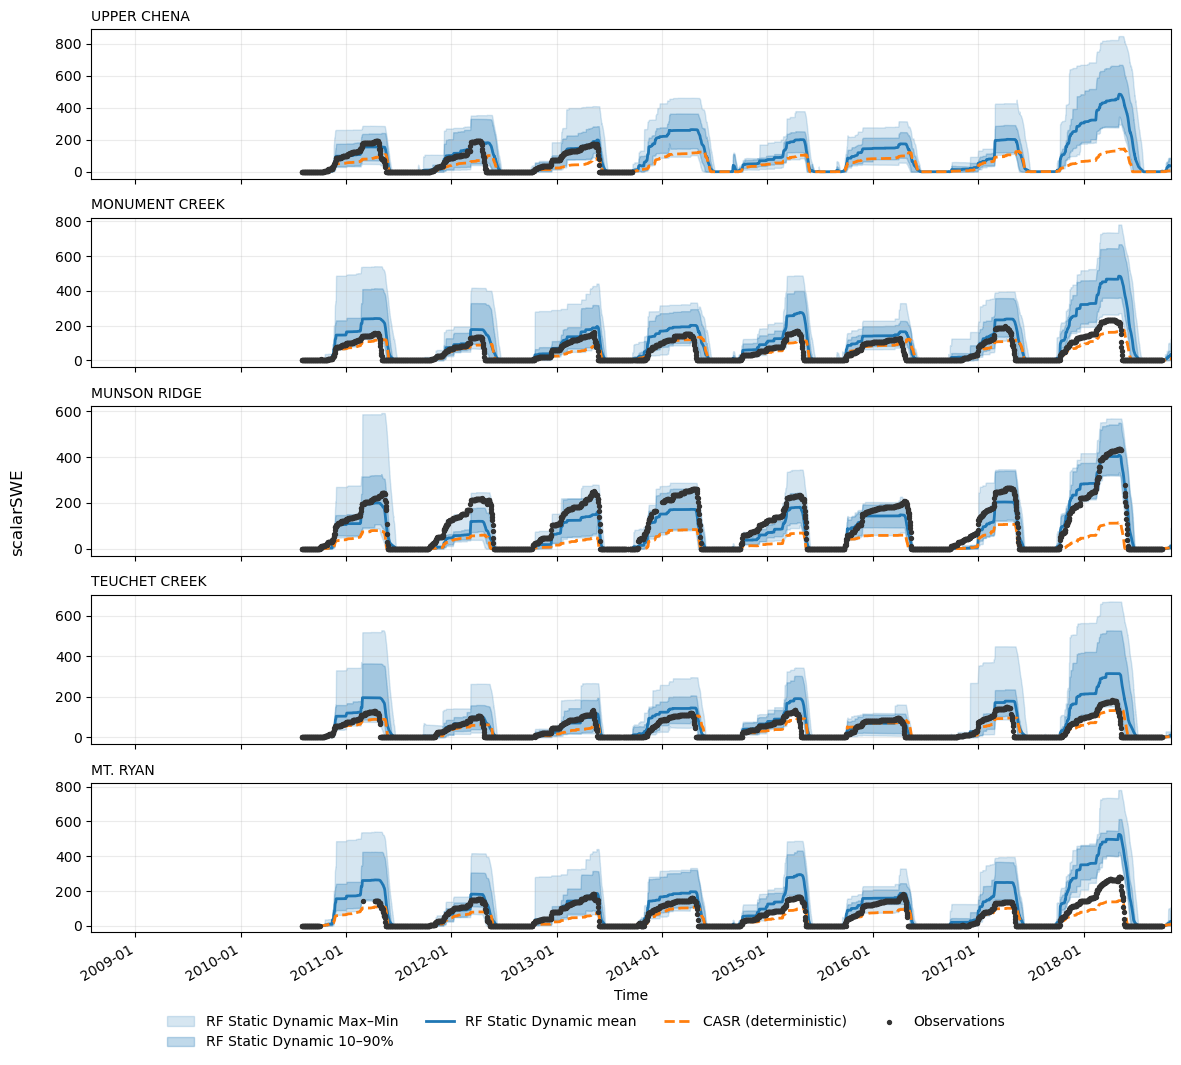

In [13]:
# --- Imports
import os
from pathlib import Path
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import xarray as xr
from dask import compute
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib import colormaps  # Updated API


# =========================
# Station helpers
# =========================
def select_top_stations_by_obs(
    ds: xr.Dataset,
    var: str = "snw",
    k: int = 8,
    time_range: Optional[Tuple[str, str]] = None,
) -> List[str]:
    """
    Return the station_id *strings* for the k stations with the most non-NaN
    observations of `var` over the given time_range (or full record if None).
    """
    da = ds[var]
    if time_range:
        start, end = time_range
        da = da.sel(time=slice(start, end))

    if "time" not in da.dims or "station_id" not in da.dims:
        raise ValueError("Expected dimensions 'time' and 'station_id' in station dataset.")

    counts = da.notnull().sum(dim="time").compute().values  # (n_stations,)
    station_ids = np.asarray(ds["station_id"].load().values).astype(str)
    order = np.argsort(-counts)  # descending
    top = station_ids[order][:k]
    return list(top)


def read_station_data_for_gru(
    ds: xr.Dataset,
    gru_id: int,
    station_id_to_gru: pd.DataFrame,
    station_filter_ids: Optional[List[str]] = None,
    var: str = "snw",
    time_range: Optional[Tuple[str, str]] = None,
) -> Dict[str, xr.DataArray]:
    """
    For a given GRU, return {station_name: dataarray_of_var}, using *string* station IDs.
    If station_filter_ids is provided, only include those stations.
    """
    sid_map = station_id_to_gru.copy()
    sid_map["station_id"] = sid_map["station_id"].astype(str)

    matching_ids = sid_map.loc[sid_map["GRU_ID"] == gru_id, "station_id"].astype(str).tolist()
    if station_filter_ids is not None:
        filter_set = {str(s) for s in station_filter_ids}
        matching_ids = [s for s in matching_ids if s in filter_set]

    if not matching_ids:
        return {}

    station_ids = np.asarray(ds["station_id"].load().values).astype(str)
    station_names = np.asarray(ds["station_name"].load().values).astype(str)

    id_to_idx = {sid: i for i, sid in enumerate(station_ids)}
    chosen_indices = [id_to_idx[sid] for sid in matching_ids if sid in id_to_idx]
    if not chosen_indices:
        return {}

    da = ds[var].isel(station_id=chosen_indices).load()
    names = [station_names[i] for i in chosen_indices]

    if time_range:
        start, end = time_range
        da = da.sel(time=slice(start, end))

    return {names[j]: da.isel(station_id=j) for j in range(len(chosen_indices))}


# =========================
# NetCDF HRU/GRU selection
# =========================
def _choose_by_id_or_single(da: xr.DataArray, dim: str, target_id, id_coord_candidates):
    """Try to select by ID coord; if not possible and size==1, take index 0; else error."""
    target_str = str(target_id)
    target_int = None
    try:
        target_int = int(target_id)
    except Exception:
        pass

    for cname in id_coord_candidates:
        if cname in da.coords and (dim in da.coords[cname].dims):
            vals = np.asarray(da.coords[cname].values)
            where = np.where(vals.astype(str) == target_str)[0]
            if where.size:
                return da.isel({dim: int(where[0])})
            if target_int is not None and np.issubdtype(vals.dtype, np.number):
                where = np.where(vals == target_int)[0]
                if where.size:
                    return da.isel({dim: int(where[0])})

    if da.sizes.get(dim, 0) == 1:
        return da.isel({dim: 0})

    if dim in da.coords:
        vals = np.asarray(da.coords[dim].values)
        if (vals.astype(str) == target_str).any():
            return da.sel({dim: target_str})
        if target_int is not None and np.issubdtype(vals.dtype, np.number) and (vals == target_int).any():
            return da.sel({dim: target_int})

    preview = {}
    for cname in [dim] + id_coord_candidates:
        if cname in da.coords and (dim in da.coords[cname].dims):
            preview[cname] = np.asarray(da.coords[cname].values)[:10].tolist()
    raise KeyError(
        f"Could not find {dim} with ID={target_id}. "
        f"Checked coords {list(preview.keys())}. First 10 values: {preview}"
    )


def open_member(nc_path: str, variable_name: str, hru_id, gru_id=None) -> Optional[xr.DataArray]:
    """
    Open one NetCDF and return a 1D time series for `variable_name`.
    """
    ds = xr.open_dataset(nc_path, chunks={"time": 500})
    if variable_name not in ds:
        return None

    da = ds[variable_name]
    if "hru" in da.dims:
        da = _choose_by_id_or_single(
            da, "hru", hru_id,
            id_coord_candidates=["hruId", "hru_id", "HRU_ID", "HRUId", "hruid"]
        )
        return da

    if "gru" in da.dims:
        if gru_id is None and "gruId" in ds.coords:
            vals = np.asarray(ds["gruId"].values)
            gru_id = int(vals[0]) if vals.size == 1 else None

        da = _choose_by_id_or_single(
            da, "gru", gru_id if gru_id is not None else 0,
            id_coord_candidates=["gruId", "gru_id", "GRU_ID", "GRUId", "gruid"]
        )
        return da

    return da


def load_ensemble(
    files: List[str], variable_name: str, hru_id: int, gru_id: Optional[int] = None
) -> Optional[xr.DataArray]:
    members = []
    for f in files:
        da = open_member(f, variable_name, hru_id, gru_id=gru_id)
        if da is not None:
            members.append(da)

    if not members:
        return None

    ensemble = xr.concat(
        members,
        dim="member",
        join="outer",
        compat="override",
        coords="minimal",
    ).chunk({"member": -1})
    return ensemble


# =========================
# Plotting
# =========================
def build_color_map(ensemble_specs: List[dict]) -> Dict[str, str]:
    """
    Stable, readable colors for each ensemble 'label'.
    """
    cmap = colormaps.get_cmap("tab10")  # Updated API
    labels = [spec["label"] for spec in ensemble_specs]
    unique_labels = list(dict.fromkeys(labels))
    return {lab: cmap(i % 10) for i, lab in enumerate(unique_labels)}


def compute_ensemble_summary(ensemble: xr.DataArray) -> Tuple[np.ndarray, ...]:
    mean_da = ensemble.mean(dim="member")
    p10_da = ensemble.quantile(0.1, dim="member")
    p90_da = ensemble.quantile(0.9, dim="member")
    vmin_da = ensemble.min(dim="member")
    vmax_da = ensemble.max(dim="member")

    mean, p10, p90, vmin, vmax = compute(mean_da, p10_da, p90_da, vmin_da, vmax_da)
    time = ensemble["time"].values
    return time, mean, p10, p90, vmin, vmax


def resolve_specs_for_gru(
    ensemble_specs: List[dict],
    variable_name: str,
    hru_id: int,
    gru_id: int,
    time_range: Optional[Tuple[str, str]],
) -> List[dict]:
    """Resolve deterministic/ensemble series for a given GRU/HRU once; reuse for that GRU's stations."""
    resolved = []
    for spec in ensemble_specs:
        label, files = spec["label"], spec["files"]
        is_det = bool(spec.get("deterministic", False))

        if is_det:
            nc = files[0]
            da = open_member(nc, variable_name, hru_id, gru_id=gru_id)
            if da is None:
                continue
            if time_range:
                da = da.sel(time=slice(*time_range))
            resolved.append({"label": label, "kind": "det", "time": da["time"].values, "values": da.values})
        else:
            ens = load_ensemble(files, variable_name, hru_id, gru_id=gru_id)
            if ens is None:
                continue
            if time_range:
                ens = ens.sel(time=slice(*time_range))
            t, mean, p10, p90, vmin, vmax = compute_ensemble_summary(ens)
            resolved.append({"label": label, "kind": "ens", "time": t, "mean": mean, "p10": p10, "p90": p90, "vmin": vmin, "vmax": vmax})
    return resolved


def plot_all_grus_one_figure(
    *,
    all_items: List[dict],
    variable_name: str,
    output_path: Path,
    time_range: Optional[Tuple[str, str]] = None,
    show: bool = False,
) -> None:
    """
    Plot ALL GRUs and their selected stations into ONE figure.
    all_items: list of dicts, each:
        {
          "gru_id": int,
          "hru_id": int,
          "station_data_dict": {station_name: xr.DataArray},
          "ensemble_specs": List[dict]  # files already filtered for this GRU
        }
    """
    # Count total subplots (one per station across all GRUs)
    total_rows = sum(len(item["station_data_dict"]) for item in all_items if item["station_data_dict"])
    if total_rows == 0:
        return

    # Build a unified color map across all ensemble labels present
    all_specs_flat = []
    for item in all_items:
        all_specs_flat.extend(item["ensemble_specs"])
    label_to_color = build_color_map(all_specs_flat)

    # Pre-resolve specs once per GRU
    for item in all_items:
        item["resolved_specs"] = resolve_specs_for_gru(
            item["ensemble_specs"],
            variable_name,
            item["hru_id"],
            item["gru_id"],
            time_range,
        )

    # Prepare figure
    fig_h = max(2.2 * total_rows, 5.0)
    fig, axes = plt.subplots(nrows=total_rows, ncols=1, figsize=(12, fig_h), sharex=True, squeeze=False)
    axes = axes.ravel()

    # Legend collection (global)
    legend_handles, legend_labels, added_for_label = [], [], set()

    # Walk through items and stations, plotting into sequential axes
    ax_idx = 0
    added_for_label = set()
    for item in all_items:
        station_data_dict = item["station_data_dict"]
        resolved_specs = item["resolved_specs"]
        if not station_data_dict or not resolved_specs:
            continue

        for station_name, obs_da in station_data_dict.items():
            ax = axes[ax_idx]
            # Ensembles
            for spec in resolved_specs:
                label, color = spec["label"], label_to_color[spec["label"]]
                if spec["kind"] == "det":
                    (line,) = ax.plot(spec["time"], spec["values"], linestyle="--", linewidth=2, color=color, label=f"{label} (deterministic)")
                    if f"{label} (deterministic)" not in added_for_label:
                        legend_handles.append(line); legend_labels.append(f"{label} (deterministic)"); added_for_label.add(f"{label} (deterministic)")
                else:
                    pmax = ax.fill_between(spec["time"], spec["vmin"], spec["vmax"], color=color, alpha=0.18)
                    p1090 = ax.fill_between(spec["time"], spec["p10"], spec["p90"], color=color, alpha=0.28)
                    (mean_line,) = ax.plot(spec["time"], spec["mean"], color=color, linewidth=2, label=f"{label} mean")
                    for tag, artist in [(f"{label} Max–Min", pmax), (f"{label} 10–90%", p1090), (f"{label} mean", mean_line)]:
                        if tag not in added_for_label:
                            legend_handles.append(artist); legend_labels.append(tag); added_for_label.add(tag)

            # Observations
            obs = obs_da.sel(time=slice(*time_range)) if time_range else obs_da
            ax.scatter(obs["time"].values, obs.values, s=8, color="0.2", zorder=3)
            # Add to legend if not already added
            if "Observations" not in added_for_label:
                legend_handles.append(ax.scatter(0, 0, s=8, color="0.2", label="Observations"))
                legend_labels.append("Observations")
                added_for_label.add("Observations")
            # Formatting
            ax.grid(True, alpha=0.25)
            # Subplot title with station name (and small GRU/HRU tags)
            ax.set_title(f"{station_name}", loc="left", fontsize=10)

            ax_idx += 1

    # Shared labels & date formatting
    axes[-1].set_xlabel("Time")
    fig.supylabel(variable_name)

    if time_range:
        start, end = time_range
        start_num = mdates.datestr2num(start)
        end_num = mdates.datestr2num(end)
        for ax in axes:
            ax.set_xlim(start_num, end_num)  # <-- lock x-axis range
            ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    else:
        for ax in axes:
            ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

    fig.autofmt_xdate()

    # One shared legend at the bottom
    fig.legend(legend_handles, legend_labels, loc="lower center", ncol=4, frameon=False, bbox_to_anchor=(0.5, 0.0))

    # Figure title summarizing content
    #fig.suptitle(f"All GRUs • {variable_name}", y=0.995)

    # Layout & save
    fig.tight_layout(rect=[0.02, 0.04, 1, 0.97])
    Path(output_path).parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(output_path, dpi=200, bbox_inches="tight")
    if show:
        plt.show()
    plt.close(fig)


# =========================
# Build ensemble specs for a GRU
# =========================
def build_ensemble_specs_for_gru(ensemble_sources: List[dict], gru_id: int) -> List[dict]:
    specs = []
    for src in ensemble_sources:
        src_dir = src["dir"]
        if not os.path.isdir(src_dir):
            continue
        files = [
            os.path.join(src_dir, f)
            for f in os.listdir(src_dir)
            if f.endswith(".nc") and any(f"G{int(gru_id):{pad}d}" in f for pad in ["02", "03", "04"])
        ]
        if not files:
            continue
        # For deterministics we keep first file by convention
        if src.get("deterministic", False) and len(files) > 1:
            files = [sorted(files)[0]]

        specs.append(
            {
                "label": src["label"],
                "files": files,
                "deterministic": bool(src.get("deterministic", False)),
            }
        )
    return specs


# =========================
# Example usage (adjust paths/vars as needed)
# =========================
if __name__ == "__main__":
    # User-configurable
    catchment = "chena"
    figure_directory = Path(f"/anvil/projects/x-ees240082/users/dcasson/gpep/{catchment}/ensemble_generation/swe_figures_rf_compare/")
    figure_directory.mkdir(parents=True, exist_ok=True)
    variable_name = "scalarSWE"
    swe_observations_path = f"/anvil/projects/x-ees240082/users/dcasson/gpep/{catchment}/snow_data/{catchment}_NorSWE.nc"
    hru_csv_path = f"/anvil/projects/x-ees240082/users/dcasson/gpep/{catchment}/gis/stations_with_hru_ids.csv"
    start_date = "2008-10-01"
    end_date = "2018-10-01"

    # Ensemble sources
    ensemble_sources = [
        {
            "label": "RF Static Dynamic",
            "dir": f"/anvil/projects/x-ees240082/users/dcasson/gpep/{catchment}/ensemble_generation/rf_best_regression_static_dynamic/summa/output/",
            "color": "C1",
            "deterministic": False,
        },
        # {
        #     "label": "LWR Static",
        #     "dir": f"/anvil/projects/x-ees240082/users/dcasson/gpep/{catchment}/ensemble_generation/lwr_best_regression_static/summa/output/",
        #     "color": "C2",
        #     "deterministic": False,
        # },
        {
            "label": "CASR",
            "dir": f"/anvil/projects/x-ees240082/users/dcasson/gpep/{catchment}/ensemble_generation/casr_remapped/summa_output",
            "color": "C3",
            "deterministic": True,
        },
    ]

    # Load SWE observations and filter
    SWE_stations_ds_complete = xr.open_dataset(swe_observations_path)
    # You must have this function in your env; keeping your original call:
    SWE_stations_ds = filter_stations_by_obs_per_year(
        SWE_stations_ds_complete, var="snw", n=0,
        start_date=start_date, end_date=end_date
    )

    # HRU/GRU mapping
    hru_ids = pd.read_csv(hru_csv_path)
    hru_ids["station_id"] = hru_ids["station_id"].astype(str)

    # Station IDs present in DS
    station_ids_in_ds = np.asarray(SWE_stations_ds["station_id"].load().values).astype(str)
    station_id_to_gru = hru_ids[hru_ids["station_id"].isin(station_ids_in_ds)]
    unique_gru_ids = station_id_to_gru["GRU_ID"].unique()

    # Top 8 station IDs (global) by obs count
    top_station_ids = select_top_stations_by_obs(SWE_stations_ds, var="snw", k=5, time_range=None)

    # Build all items for a single-figure plot
    all_items = []
    for gru_id in unique_gru_ids:
        # Stations for this GRU, restricted to the global top-8 by obs
        station_data = read_station_data_for_gru(
            SWE_stations_ds,
            gru_id=gru_id,
            station_id_to_gru=station_id_to_gru,
            station_filter_ids=top_station_ids,  # maintain same selection across GRUs
            var="snw",
            time_range=("2010-08-01", "2018-10-31"),
        )
        if not station_data:
            continue

        specs = build_ensemble_specs_for_gru(ensemble_sources, gru_id)
        if not specs:
            continue

        hru_match = hru_ids.loc[hru_ids["GRU_ID"] == gru_id, "HRU_ID"].values
        if hru_match.size == 0:
            continue
        hru_id = int(hru_match[0])

        all_items.append(
            {
                "gru_id": int(gru_id),
                "hru_id": hru_id,
                "station_data_dict": station_data,
                "ensemble_specs": specs,
            }
        )

    # ONE FIGURE for all GRUs & stations
    out = figure_directory / f"compare_ALL_GRUs_{catchment}_{variable_name}.png"
    plot_all_grus_one_figure(
        all_items=all_items,
        variable_name=variable_name,
        output_path=out,
        time_range=("2008-08-01", "2018-10-31"),
        show=True,  # set True for interactive
    )